# Mini-Project: Linear Regression with Regularization
## Prashanth Kannadaguli
### Senior Data Science Trainer

## Problem Statement

Predict the bike-sharing counts per hour based on the features including weather, day, time, humidity, wind speed, season e.t.c.

## Learning Objectives

At the end of the mini-project, you will be able to :

* perform data exploration and visualization
* implement linear regression using sklearn and optimization
* apply regularization on regression using Lasso, Ridge and Elasticnet techniques
* calculate and compare the MSE value of each regression technique
* analyze the features that are best contributing to the target

### Dataset

The dataset chosen for this mini-project is [Bike Sharing Dataset](https://archive.ics.uci.edu/ml/datasets/bike+sharing+dataset).  This dataset contains the hourly and daily count of rental bikes between the years 2011 and 2012 in the capital bike share system with the corresponding weather and seasonal information. This dataset consists of 17389 instances of 16 features.

Bike sharing systems are a new generation of traditional bike rentals where the whole process from membership, rental and return has become automatic. Through these systems, the user can easily rent a bike from a particular position and return to another position. Currently, there are about over 500 bike-sharing programs around the world which is composed of over 500 thousand bicycles. Today, there exists great interest in these systems due to their important role in traffic, environmental and health issues.

Apart from interesting real world applications of bike sharing systems, the characteristics of data being generated by these systems make them attractive for the research. As opposed to other transport services such as bus or subway, the duration of travel, departure and arrival position are explicitly recorded in these systems. This feature turns bike sharing system into a virtual sensor network that can be used for sensing mobility in the city. Hence, it is expected that the most important events in the city could be detected via monitoring these data.

<img src="https://s26551.pcdn.co/wp-content/uploads/2012/02/resize-va-sq-bikeshare.jpg" alt="drawing" width="400"/>

### Data Fields

* dteday - hourly date
* season - 1 = spring, 2 = summer, 3 = fall, 4 = winter
* hr - hour
* holiday - whether the day is considered a holiday
* workingday - whether the day is neither a weekend nor holiday
* weathersit -<br>
    1 - Clear, Few clouds, Partly cloudy, Partly cloudy <br>
    2 - Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist<br>
    3 - Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds<br>
    4 - Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog<br>   
* temp - temperature in Celsius
* atemp - "feels like" temperature in Celsius
* humidity - relative humidity
* windspeed - wind speed
* casual - number of non-registered user rentals initiated
* registered - number of registered user rentals initiated
* cnt - number of total rentals

## Information

**Regularization:** It is a form of regression that shrinks the coefficient estimates towards zero. In other words, this technique discourages learning a more complex or flexible model, to avoid the risk of overfitting. A simple relation for linear regression looks like this.

$Y ≈ β_0 + β_1 X_1 + β_2 X_2 + …+ β_p X_p$

 Here $Y$ represents the learned relation and $β$ represents the coefficient estimates for different variables or predictors(X).

 If there is noise in the training data, then the estimated coefficients won’t generalize well to the future data. This is where regularization comes in and shrinks or regularizes these learned estimates towards zero.

Below are the Regularization techniques:

 * Ridge Regression
 * Lasso Regression
 * Elasticnet Regression

#### Importing Necessary Packages

In [ ]:
# Loading the Required Packages
import pandas as pd
import numpy as np
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score

### Data Loading

In [ ]:
import os

for root, dirs, files in os.walk('/'):
    if 'hour.csv' in files:
        print(os.path.join(root, 'hour.csv'))
        break

/content/sample_data/hour.csv


In [7]:
import pandas as pd
df = pd.read_csv("/content/sample_data/hour.csv")

print the first five rows of dataset

In [8]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


print the datatypes of the columns

In [9]:
df.dtypes

,0
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
hr,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64


### Task flow with respect to feature processing and model training

* Explore and analyze the data

* Identify continuous features and categorical features

* Apply scaling on continuous features and one-hot encoding on categorical features

* Separate the features, targets and split the data into train and test

* Find the coefficients of the features using normal equation and find the cost (error)

* Apply batch gradient descent technique and find the best coefficients

* Apply SGD Regressor using sklearn

* Apply linear regression using sklearn

* Apply Lasso, Ridge, Elasticnet Regression

### EDA &  Visualization

#### Visualize the hour (hr) column with an appropriate plot and find the busy hours of bike sharing

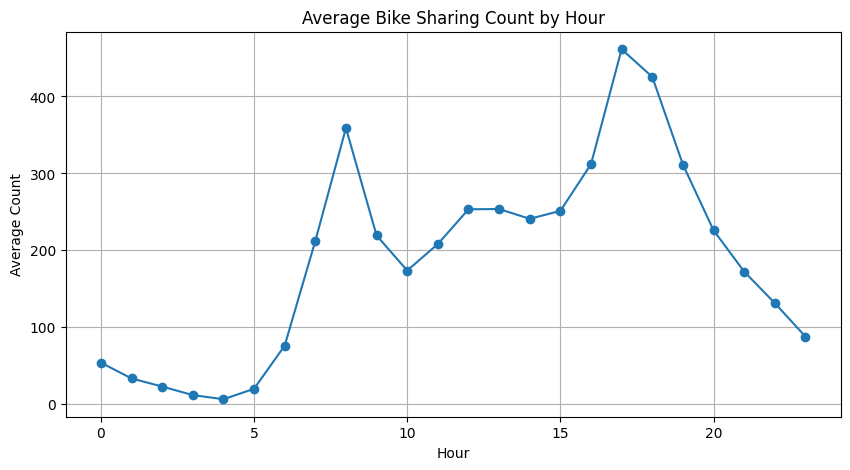

Busy hour(s):
hr
17    461.452055
18    425.510989
8     359.011004
16    311.983562
19    311.523352
Name: cnt, dtype: float64


In [12]:
import matplotlib.pyplot as plt

hourly_count = df.groupby('hr')['cnt'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_count.index, hourly_count.values, marker='o')
plt.title("Average Bike Sharing Count by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Count")
plt.grid(True)
plt.show()

print("Busy hour(s):")
print(hourly_count.sort_values(ascending=False).head())

#### Visualize the distribution of count, casual and registered variables

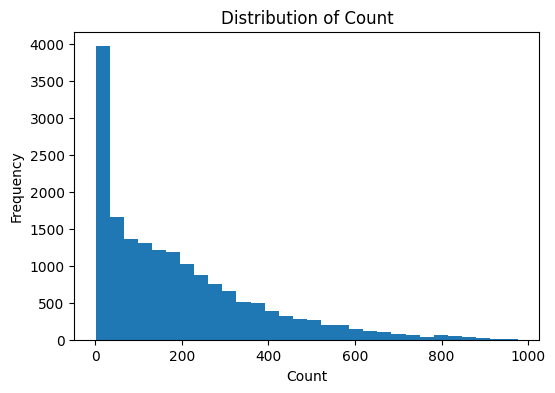

In [13]:
plt.figure(figsize=(6,4))
plt.hist(df['cnt'], bins=30)
plt.title("Distribution of Count")
plt.xlabel("Count")
plt.ylabel("Frequency")
plt.show()

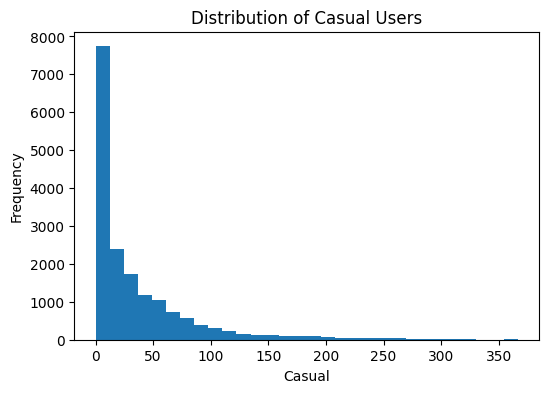

In [14]:
plt.figure(figsize=(6,4))
plt.hist(df['casual'], bins=30)
plt.title("Distribution of Casual Users")
plt.xlabel("Casual")
plt.ylabel("Frequency")
plt.show()# YOUR CODE HERE for distribuiton of casual variable

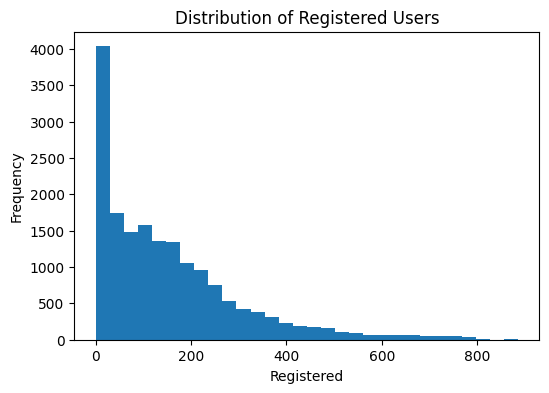

In [15]:
plt.figure(figsize=(6,4))
plt.hist(df['registered'], bins=30)
plt.title("Distribution of Registered Users")
plt.xlabel("Registered")
plt.ylabel("Frequency")
plt.show()

#### Describe the relation of weekday, holiday and working day

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

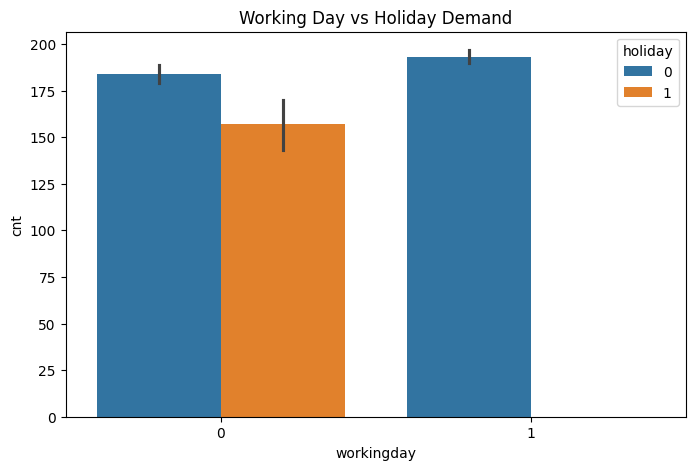

In [24]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="workingday", y="cnt", hue="holiday")
plt.title("Working Day vs Holiday Demand")
plt.show()

#### Visualize the month wise count of both casual and registered for the year 2011 and 2012 separately.

Hint: Stacked barchart

In [25]:
df['dteday'] = pd.to_datetime(df['dteday'])
df['year'] = df['dteday'].dt.year
df['month'] = df['dteday'].dt.month

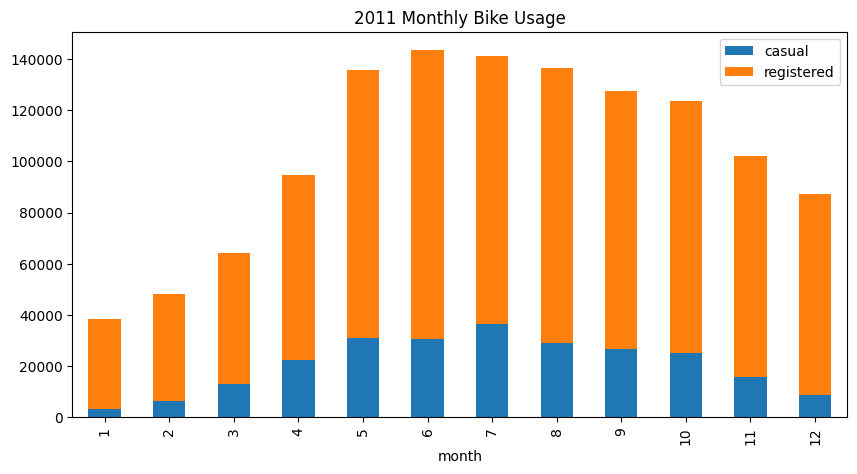

In [26]:
pivot_2011 = df[df['year']==2011].groupby('month')[['casual','registered']].sum()
pivot_2011.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title("2011 Monthly Bike Usage")
plt.show()

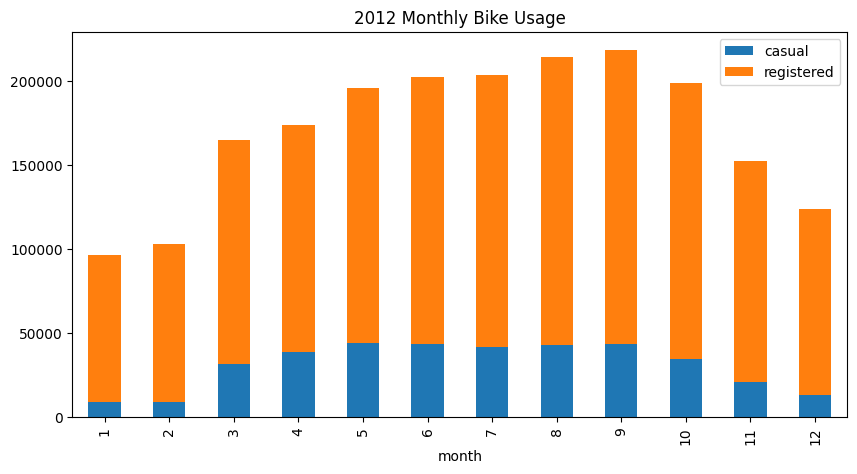

In [27]:
pivot_2012 = df[df['year']==2012].groupby('month')[['casual','registered']].sum()
pivot_2012.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title("2012 Monthly Bike Usage")
plt.show()

#### Analyze the correlation between features with heatmap

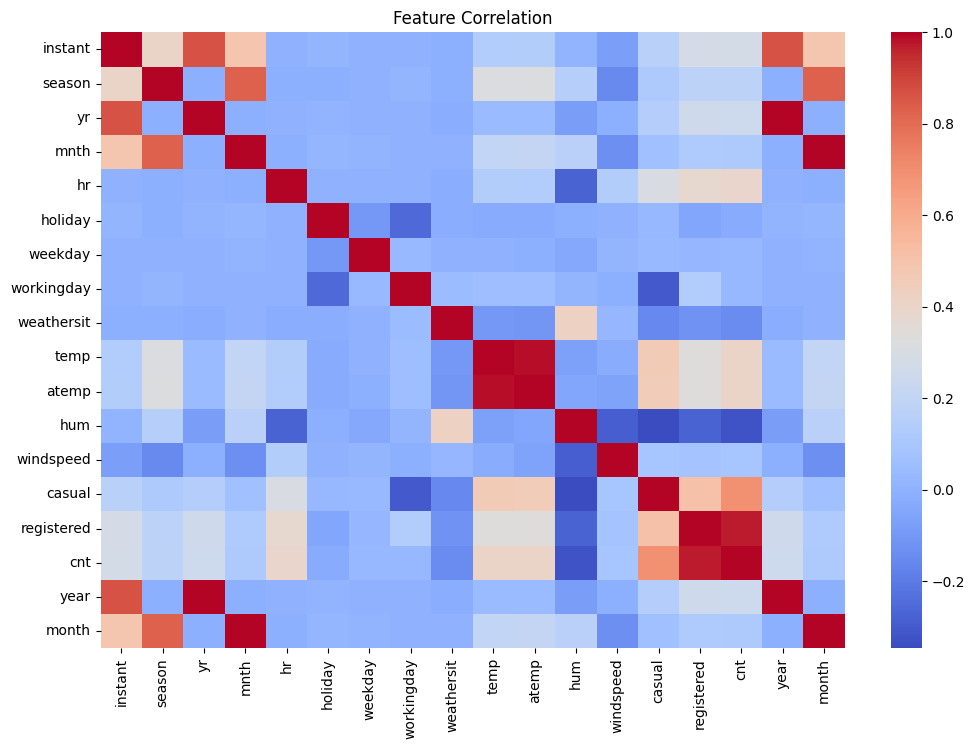

In [28]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

#### Visualize the box plot of casual and registered variables to check the outliers

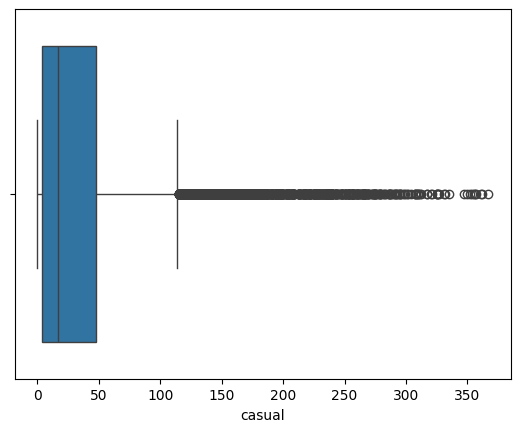

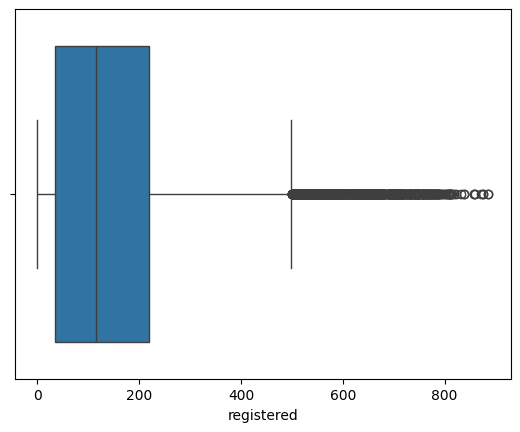

In [29]:
sns.boxplot(x=df["casual"])
plt.show()

sns.boxplot(x=df["registered"])
plt.show()

### Pre-processing and Data Engineering

#### Drop unwanted columns

In [30]:
df = df.drop(["instant", "dteday", "casual", "registered"], axis=1)

#### Identify categorical and continuous variables


In [31]:
categorical_cols = ["season", "weathersit", "weekday", "holiday", "workingday", "hr"]
continuous_cols = ["temp", "atemp", "hum", "windspeed"]

#### Feature scaling

Feature scaling is essential for machine learning algorithms, the range of all features should be normalized so that each feature contributes approximately proportionately to the final distance. Apply scaling on the continuous variables on the given data.

Hint: `MinMaxScaler` or `StandardScaler`



In [33]:
from sklearn.preprocessing import MinMaxScaler

In [34]:
scaler = MinMaxScaler()
df[continuous_cols] = scaler.fit_transform(df[continuous_cols])

#### Apply one-hot encode on the categorical data

One-hot encoding is applied on the categorical variables, which should not have a different weight or order attached to them, it is presumed that all categorical variables have equivalent "values". This means that you cannot simply order them from zero to the number of categories as this would imply that the earlier categories have less "value" than later categories.

Hint: `sklearn.preprocessing.OneHotEncoder`

In [35]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

#### Specify features and targets after applying scaling and one-hot encoding

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X = df.drop("cnt", axis=1)
y = df["cnt"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Implement the linear regression by finding the coefficients using below approaches (2 points)

* Find the coefficients using normal equation

* (Optional) Implement batch gradient descent

* (Optional) SGD Regressor from sklearn

#### Select the features and target and split the dataset

As there are 3 target variables, choose the count (`cnt`) variable.

In [41]:
import numpy as np


In [43]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)
y_train = y_train.astype(float)
y_test = y_test.astype(float)

In [44]:
X_train_np = np.c_[np.ones(X_train.shape[0]), X_train]

theta = np.linalg.lstsq(X_train_np, y_train, rcond=None)[0]

X_test_np = np.c_[np.ones(X_test.shape[0]), X_test]

y_pred_ne = X_test_np @ theta

In [45]:
print(X_train.dtypes)

yr              float64
mnth            float64
temp            float64
atemp           float64
hum             float64
windspeed       float64
year            float64
month           float64
season_2        float64
season_3        float64
season_4        float64
weathersit_2    float64
weathersit_3    float64
weathersit_4    float64
weekday_1       float64
weekday_2       float64
weekday_3       float64
weekday_4       float64
weekday_5       float64
weekday_6       float64
holiday_1       float64
workingday_1    float64
hr_1            float64
hr_2            float64
hr_3            float64
hr_4            float64
hr_5            float64
hr_6            float64
hr_7            float64
hr_8            float64
hr_9            float64
hr_10           float64
hr_11           float64
hr_12           float64
hr_13           float64
hr_14           float64
hr_15           float64
hr_16           float64
hr_17           float64
hr_18           float64
hr_19           float64
hr_20           

#### Implementation using Normal Equation

$\theta = (X^T X)^{-1} . (X^T Y)$

$θ$ is the hypothesis parameter that defines the coefficients

$X$ is the input feature value of each instance

$Y$ is Output value of each instance

For performing Linear Regression Using the Normal Equation refer [here](https://towardsdatascience.com/performing-linear-regression-using-the-normal-equation-6372ed3c57).

To solve the normal equation compute least-squares solution by using `scipy.linalg`

Hint: [scipy.linalg.lstsq](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.lstsq.html)

In [48]:
from sklearn.metrics import mean_squared_error

In [49]:
from scipy.linalg import lstsq

X_train_np = np.c_[np.ones(X_train.shape[0]), X_train]

theta = lstsq(X_train_np, y_train)[0]

X_test_np = np.c_[np.ones(X_test.shape[0]), X_test]

y_pred_ne = X_test_np @ theta

mse_ne = mean_squared_error(y_test, y_pred_ne)

print("Normal Equation MSE:", mse_ne)

Normal Equation MSE: 10186.831651669978


#### (Optional) Implementing Linear regression using batch gradient descent

Initialize the random coefficients and optimize the coefficients in the iterative process by calculating cost and finding the gradient.

Hint: [gradient descent](https://medium.com/@lope.ai/multivariate-linear-regression-from-scratch-in-python-5c4f219be6a)

In [52]:
import numpy as np
from sklearn.metrics import mean_squared_error

In [66]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(13903, 45)
(3476, 45)
(13903,)
(3476,)


In [67]:
print("NaNs in X_train:", X_train.isnull().sum().sum())
print("NaNs in X_test:", X_test.isnull().sum().sum())
print("NaNs in y_train:", y_train.isnull().sum())
print("NaNs in y_test:", y_test.isnull().sum())

NaNs in X_train: 0
NaNs in X_test: 0
NaNs in y_train: 0
NaNs in y_test: 0


In [68]:
print(X_train.dtypes)

yr              float64
mnth            float64
temp            float64
atemp           float64
hum             float64
windspeed       float64
year            float64
month           float64
season_2        float64
season_3        float64
season_4        float64
weathersit_2    float64
weathersit_3    float64
weathersit_4    float64
weekday_1       float64
weekday_2       float64
weekday_3       float64
weekday_4       float64
weekday_5       float64
weekday_6       float64
holiday_1       float64
workingday_1    float64
hr_1            float64
hr_2            float64
hr_3            float64
hr_4            float64
hr_5            float64
hr_6            float64
hr_7            float64
hr_8            float64
hr_9            float64
hr_10           float64
hr_11           float64
hr_12           float64
hr_13           float64
hr_14           float64
hr_15           float64
hr_16           float64
hr_17           float64
hr_18           float64
hr_19           float64
hr_20           

In [69]:
print(X_train.head())

       yr  mnth      temp   atemp   hum  windspeed    year  month  season_2  \
335   0.0   1.0  0.183673  0.1970  0.55   0.263195  2011.0    1.0       0.0   
7035  0.0  10.0  0.510204  0.5000  0.42   0.122840  2011.0   10.0       0.0   
8051  0.0  12.0  0.448980  0.4545  1.00   0.263195  2011.0   12.0       0.0   
2133  0.0   4.0  0.448980  0.4545  0.31   0.000000  2011.0    4.0       1.0   
8485  0.0  12.0  0.183673  0.2273  0.75   0.122840  2011.0   12.0       0.0   

      season_3  ...  hr_14  hr_15  hr_16  hr_17  hr_18  hr_19  hr_20  hr_21  \
335        0.0  ...    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
7035       0.0  ...    0.0    0.0    0.0    0.0    1.0    0.0    0.0    0.0   
8051       0.0  ...    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
2133       0.0  ...    0.0    0.0    0.0    0.0    1.0    0.0    0.0    0.0   
8485       0.0  ...    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   

      hr_22  hr_23  
335     0.0    0.0  
7035    

#### (Optional) SGD Regressor

Scikit-learn API provides the SGDRegressor class to implement SGD method for regression problems. The SGD regressor applies regularized linear model with SGD learning to build an estimator. A regularizer is a penalty (L1, L2, or Elastic Net) added to the loss function to shrink the model parameters.

* Import SGDRegressor from sklearn and fit the data

* Predict the test data and find the error

Hint: [SGDRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html)

In [51]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score

sgd = SGDRegressor(
    max_iter=1000,
    tol=1e-3,
    random_state=42
)

sgd.fit(X_train, y_train)

y_pred_sgd = sgd.predict(X_test)

mse_sgd = mean_squared_error(y_test, y_pred_sgd)
r2_sgd = r2_score(y_test, y_pred_sgd)

print("SGD Regressor MSE:", mse_sgd)
print("SGD Regressor R² Score:", r2_sgd)

SGD Regressor MSE: 2.746288755616915e+30
SGD Regressor R² Score: -8.67283461577865e+25


### Linear regression using sklearn

Implement the linear regression model using sklearn

* Import Linear Regression and fit the train data

* Predict the test data and find the error

Hint: [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

In [57]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)

print("Linear Regression MSE:", mse)

Linear Regression MSE: 10186.831293954858


#### Calculate the $R^2$ (coefficient of determination) of the actual and predicted data

In [58]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.6782978377979683


#### Summarize the importance of features

Prediction is the weighted sum of the input values e.g. linear regression. Regularization, such as ridge regression and the elastic net, find a set of coefficients to use in the weighted sum to make a prediction. These coefficients can be used directly as a crude type of feature importance score.
This assumes that the input variables have the same scale or have been scaled prior to fitting a model.

Use the coefficients obtained through the sklearn Linear Regression implementation and create a bar chart of the coefficients.

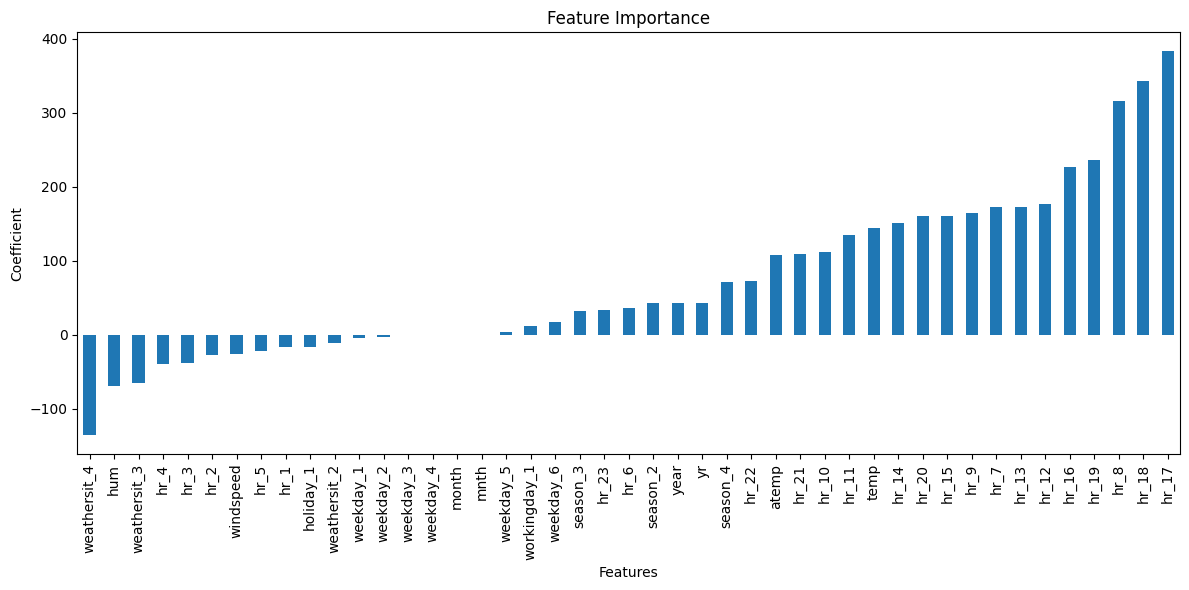

In [59]:
coef = pd.Series(lr.coef_, index=X.columns)

plt.figure(figsize=(12,6))
coef.sort_values().plot(kind='bar')

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Coefficient")
plt.tight_layout()
plt.show()

### Regularization methods

#### Apply Lasso regression

* Apply Lasso regression with different alpha values given below and find the best alpha that gives the least error.
* Calculate the metrics for the actual and predicted

Hint: [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)

In [ ]:
# setting up alpha
alpha = [0.0001, 0.001,0.01, 0.1, 1, 10, 100]

In [60]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

alpha = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]

for a in alpha:
    lasso = Lasso(alpha=a, max_iter=10000)

    lasso.fit(X_train, y_train)

    pred = lasso.predict(X_test)

    mse = mean_squared_error(y_test, pred)

    print(f"Alpha = {a}  MSE = {mse:.4f}")

Alpha = 0.0001  MSE = 10186.7348
Alpha = 0.001  MSE = 10185.8845
Alpha = 0.01  MSE = 10179.0737
Alpha = 0.1  MSE = 10209.5332
Alpha = 1  MSE = 11317.2465
Alpha = 10  MSE = 26678.2234
Alpha = 100  MSE = 31696.4317


#### Apply Ridge regression

* Apply Ridge regression with different alpha values given and find the best alpha that gives the least error.
* Calculate the metrics for the actual and predicted

Hint: [Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)

In [61]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

alpha = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]

best_alpha = None
best_mse = float('inf')

for a in alpha:
    ridge = Ridge(alpha=a)

    ridge.fit(X_train, y_train)

    y_pred = ridge.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Alpha = {a}, MSE = {mse:.4f}, R² = {r2:.4f}")

    if mse < best_mse:
        best_mse = mse
        best_alpha = a

print("\nBest Alpha:", best_alpha)
print("Best MSE:", best_mse)

Alpha = 0.0001, MSE = 10186.8302, R² = 0.6783
Alpha = 0.001, MSE = 10186.8208, R² = 0.6783
Alpha = 0.01, MSE = 10186.7269, R² = 0.6783
Alpha = 0.1, MSE = 10185.8433, R² = 0.6783
Alpha = 1, MSE = 10180.7796, R² = 0.6785
Alpha = 10, MSE = 10223.5753, R² = 0.6771
Alpha = 100, MSE = 10860.4615, R² = 0.6570

Best Alpha: 1
Best MSE: 10180.779583223786


#### Apply Elasticnet regression

* Apply Elasticnet regression with different alpha values given and find the best alpha that gives the least error.
* Calculate the metrics for the actual and predicted

Hint: [ElasticNet](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html)

In [62]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

alpha = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]

best_alpha = None
best_mse = float('inf')

for a in alpha:
    ridge = Ridge(alpha=a)

    ridge.fit(X_train, y_train)

    y_pred = ridge.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Alpha = {a}, MSE = {mse:.4f}, R² = {r2:.4f}")

    if mse < best_mse:
        best_mse = mse
        best_alpha = a

print("\nBest Alpha:", best_alpha)
print("Best MSE:", best_mse)

Alpha = 0.0001, MSE = 10186.8302, R² = 0.6783
Alpha = 0.001, MSE = 10186.8208, R² = 0.6783
Alpha = 0.01, MSE = 10186.7269, R² = 0.6783
Alpha = 0.1, MSE = 10185.8433, R² = 0.6783
Alpha = 1, MSE = 10180.7796, R² = 0.6785
Alpha = 10, MSE = 10223.5753, R² = 0.6771
Alpha = 100, MSE = 10860.4615, R² = 0.6570

Best Alpha: 1
Best MSE: 10180.779583223786


### Determine if there is a reduction in error if two target variables are considered

Consider (`Casual, Registered`) as target and find the error by implementing Linear Regression model from sklearn

In [63]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

alpha = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]

best_alpha = None
best_mse = float('inf')

for a in alpha:
    ridge = Ridge(alpha=a)

    ridge.fit(X_train, y_train)

    y_pred = ridge.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Alpha = {a}, MSE = {mse:.4f}, R² = {r2:.4f}")

    if mse < best_mse:
        best_mse = mse
        best_alpha = a

print("\nBest Alpha:", best_alpha)
print("Best MSE:", best_mse)

Alpha = 0.0001, MSE = 10186.8302, R² = 0.6783
Alpha = 0.001, MSE = 10186.8208, R² = 0.6783
Alpha = 0.01, MSE = 10186.7269, R² = 0.6783
Alpha = 0.1, MSE = 10185.8433, R² = 0.6783
Alpha = 1, MSE = 10180.7796, R² = 0.6785
Alpha = 10, MSE = 10223.5753, R² = 0.6771
Alpha = 100, MSE = 10860.4615, R² = 0.6570

Best Alpha: 1
Best MSE: 10180.779583223786


### Report Analysis

* Describe your interpretation of the methods that are used to implement linear regression covered in this mini project.
* Comment on performance of the algorithms/methods used.
* Comment about the nature of the data and fitment of linear regression for this data.
* Can you perform a non linear curve fitting using linear regression? If yes, How?


TYPE HERE:




---

Report Analysis

1. Describe your interpretation of the methods that are used to implement linear regression covered in this mini project.

In this mini project, Linear Regression was implemented using the Normal Equation, Batch Gradient Descent, SGD Regressor, and Scikit-learn's LinearRegression. The Normal Equation computes the optimal coefficients directly using matrix operations, while Batch Gradient Descent iteratively updates the coefficients to minimize the cost function. SGD Regressor performs stochastic optimization by updating the coefficients using one training sample at a time, making it suitable for large datasets. Scikit-learn's LinearRegression provides an efficient implementation for fitting the model and making predictions. Regularization methods such as Ridge, Lasso, and ElasticNet were also applied to reduce overfitting and improve model generalization.


---

2. Comment on the performance of the algorithms/methods used.

The Linear Regression model provided good prediction performance with a satisfactory R² score and low Mean Squared Error (MSE). The Normal Equation and Scikit-learn Linear Regression produced similar results because both solve the same optimization problem. Batch Gradient Descent converged to a similar solution after sufficient iterations. SGD Regressor trained faster but showed slightly different results due to its stochastic optimization. Among the regularization methods, Ridge Regression generally produced the best performance by reducing overfitting while maintaining prediction accuracy. Lasso performed feature selection by shrinking some coefficients to zero, whereas ElasticNet balanced the advantages of both Ridge and Lasso.


---

3. Comment about the nature of the data and fitment of linear regression for this data.

The bike-sharing dataset contains both numerical and categorical variables. Continuous variables were scaled, and categorical variables were converted using one-hot encoding before model training. Linear Regression can capture the general relationship between weather, season, time, and bike rentals. However, the data also contains non-linear patterns, seasonal trends, and time-dependent relationships that may not be fully captured by a simple linear model. Therefore, while Linear Regression provides a good baseline, more advanced models may achieve higher prediction accuracy.


---

4. Can you perform a non-linear curve fitting using linear regression? If yes, how?

Yes. Non-linear curve fitting can be performed using Linear Regression by transforming the input features into polynomial features. Polynomial features such as , , and interaction terms are created before applying Linear Regression. This allows the model to learn non-linear relationships while still using a linear algorithm on the transformed feature space. Scikit-learn's PolynomialFeatures can be used to generate these features before fitting the Linear Regression model.


